In [1]:
# - Import the SynNet architecture class
from rockpool.nn.networks import SynNet

# - Build a simple SynNet with three hidden layers
net = SynNet(
    n_channels = 16,                        # Number of input channels
    n_classes = 1,                          # Number of output classes (i.e. output channels)
    size_hidden_layers = [24, 24, 24],      # Number of neurons in each hidden layer
    time_constants_per_layer = [2, 4, 8],   # Number of time constants in each hidden layer
)
print(net)

/home/igavier_umass_edu/.conda/envs/xyloIMU/lib/python3.9/site-packages/rockpool/nn/networks/__init__.py:15: UserWarning: This module needs to be ported to the v2 API.
  warnings.warn(f"{err}")
/home/igavier_umass_edu/.conda/envs/xyloIMU/lib/python3.9/site-packages/rockpool/nn/networks/__init__.py:20: UserWarning: This module needs to be ported to the v2 API.
  warnings.warn(f"{err}")


SynNet  with shape (16, 1) {
    TorchSequential 'seq' with shape (16, 1) {
        LinearTorch '0_linear' with shape (16, 24)
        LIFTorch '0_neurons' with shape (24, 24)
        LinearTorch '1_linear' with shape (24, 24)
        LIFTorch '1_neurons' with shape (24, 24)
        LinearTorch '2_linear' with shape (24, 24)
        LIFTorch '2_neurons' with shape (24, 24)
        LinearTorch 'out_linear' with shape (24, 1)
        LIFTorch 'out_neurons' with shape (1, 1)
    }
}


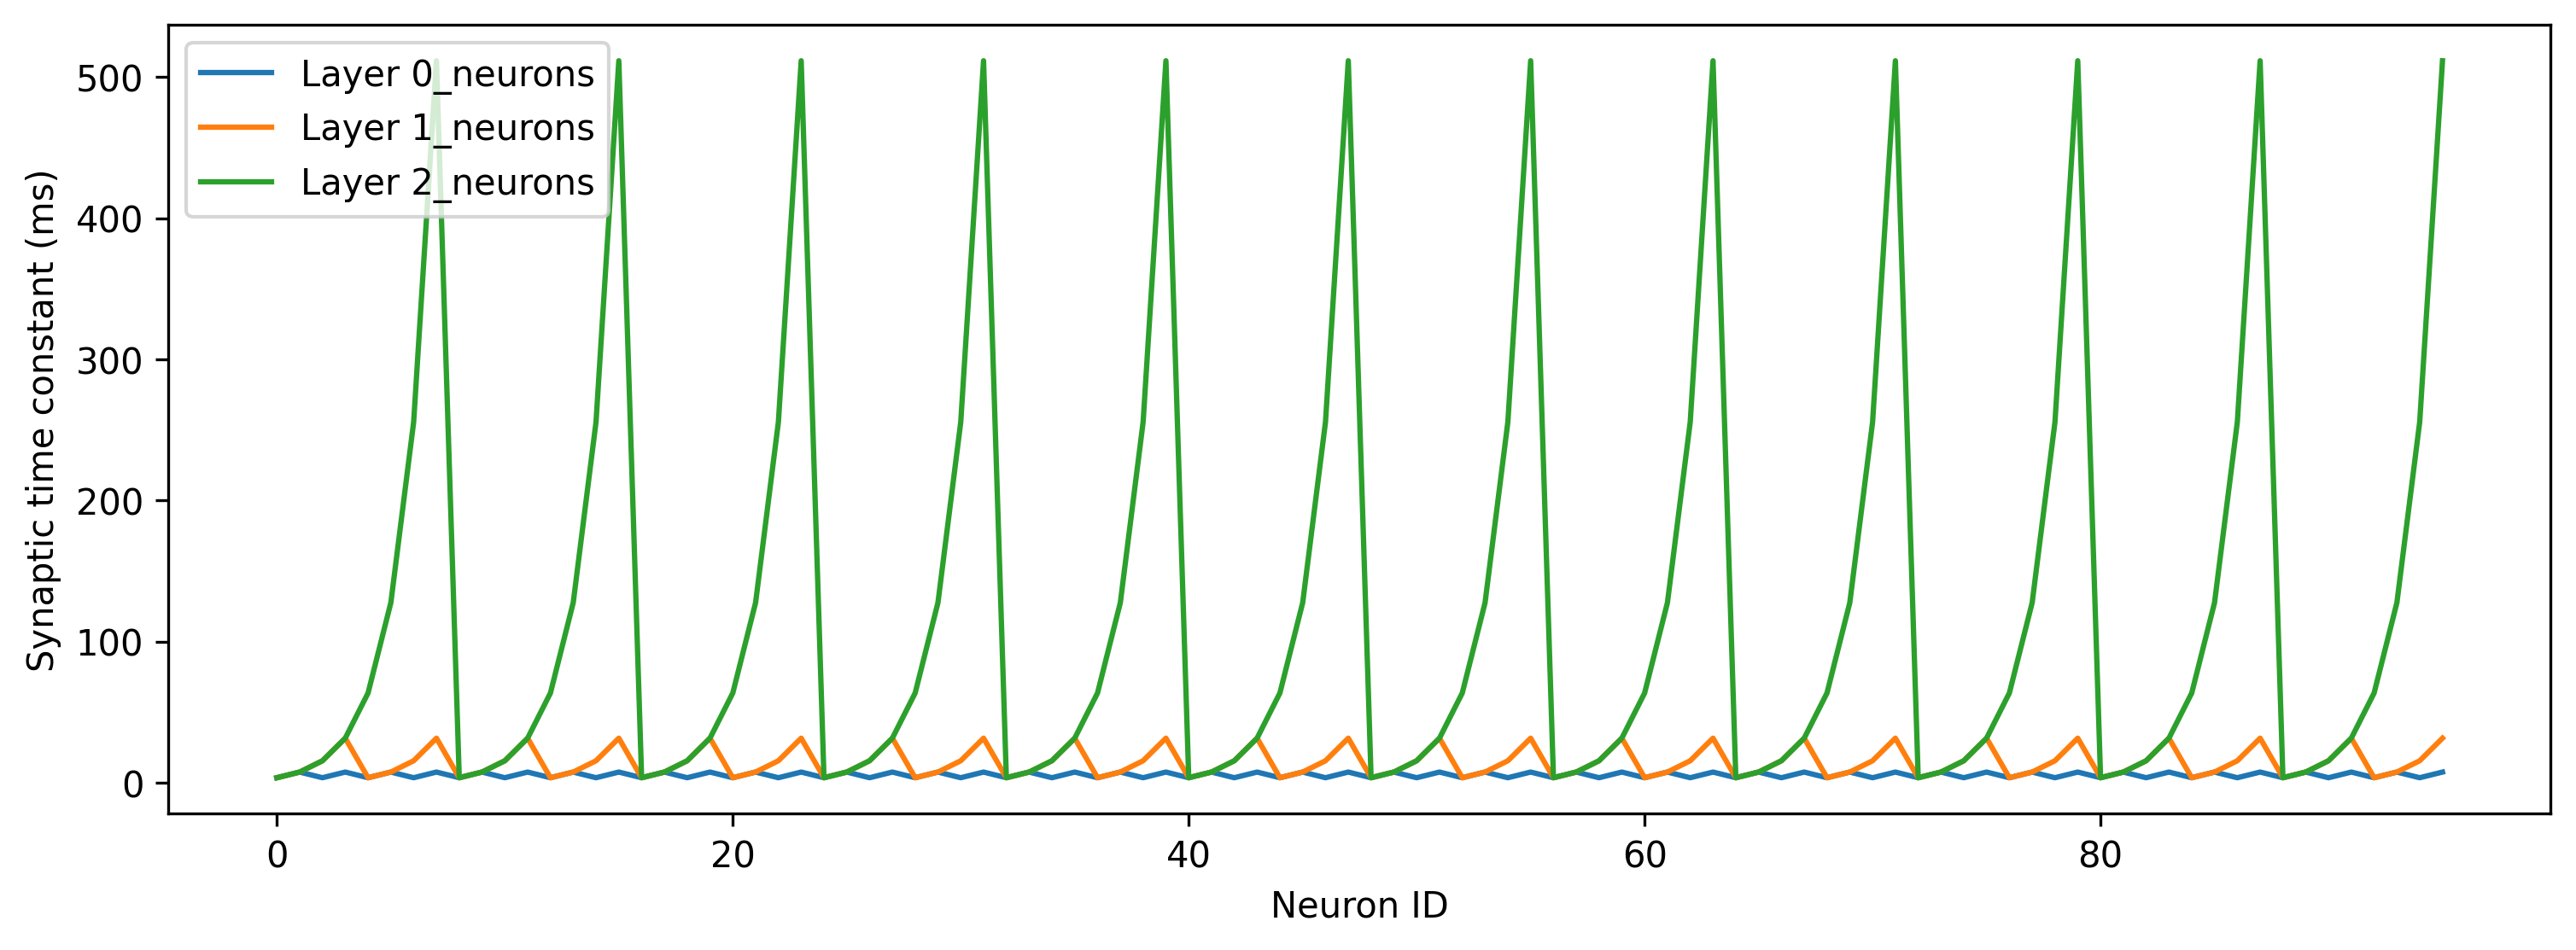

In [4]:
# - Import the matplotlib plotting library
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 4]
plt.rcParams["figure.dpi"] = 300

# - Plot the synaptic time constants for each layer
for lyr in net.lif_names[:-1]:
    plt.plot(net.seq[lyr].tau_syn / 1e-3, label = f"Layer {lyr}")

plt.xlabel('Neuron ID')
plt.ylabel('Synaptic time constant (ms)')
plt.legend();

In [3]:
# - Show the internal `Sequential` module
print(net.seq)

# - Print the list of neuron layer names
print(f"lif_names: {net.lif_names}")

TorchSequential 'seq' with shape (16, 1) {
    LinearTorch '0_linear' with shape (16, 24)
    LIFTorch '0_neurons' with shape (24, 24)
    LinearTorch '1_linear' with shape (24, 24)
    LIFTorch '1_neurons' with shape (24, 24)
    LinearTorch '2_linear' with shape (24, 24)
    LIFTorch '2_neurons' with shape (24, 24)
    LinearTorch 'out_linear' with shape (24, 1)
    LIFTorch 'out_neurons' with shape (1, 1)
}
lif_names: ['0_neurons', '1_neurons', '2_neurons', 'out_neurons']


In [4]:
lyr = net.seq[net.lif_names[0]]
print(lyr)

lyr_out = net.seq[-1]
print(lyr_out)

LIFTorch '0_neurons' with shape (24, 24)
LIFTorch 'out_neurons' with shape (1, 1)


In [5]:
for name, lyr in net.seq.modules().items():
    if 'linear' in name:
        print(lyr)

LinearTorch '0_linear' with shape (16, 24)
LinearTorch '1_linear' with shape (24, 24)
LinearTorch '2_linear' with shape (24, 24)
LinearTorch 'out_linear' with shape (24, 1)


In [6]:
n_epochs = 10
n_batch = 1
n_time = 100
n_channels = 4
n_classes = 1

# - Generate a SynNet
net = SynNet(
    n_channels=n_channels,
    n_classes=n_classes,
    size_hidden_layers=[4],
    )

# - Import torch training utilities
import torch
from torch.optim import Adam
from torch.nn import MSELoss

# - Try to use tqdm
try:
    from tqdm.notebook import trange
except:
    trange = range

# - Get the optimiser functions
optimizer = Adam(net.parameters().astorch(), lr=1e-3)

# - Loss function
loss_fun = MSELoss()

# - Record the loss values over training iterations
accuracy = []
loss_t = []

In [7]:
input_sp = (torch.rand(1, 100, 4) < 0.01) * 1.0
target_sp = torch.ones(1, 100, 1)

for epoch in trange(n_epochs):
    optimizer.zero_grad()

    output, _, _ = net(input_sp)

    loss = loss_fun(output, target_sp)

    loss.backward()
    optimizer.step()

  0%|          | 0/10 [00:00<?, ?it/s]

In [2]:
import numpy as np

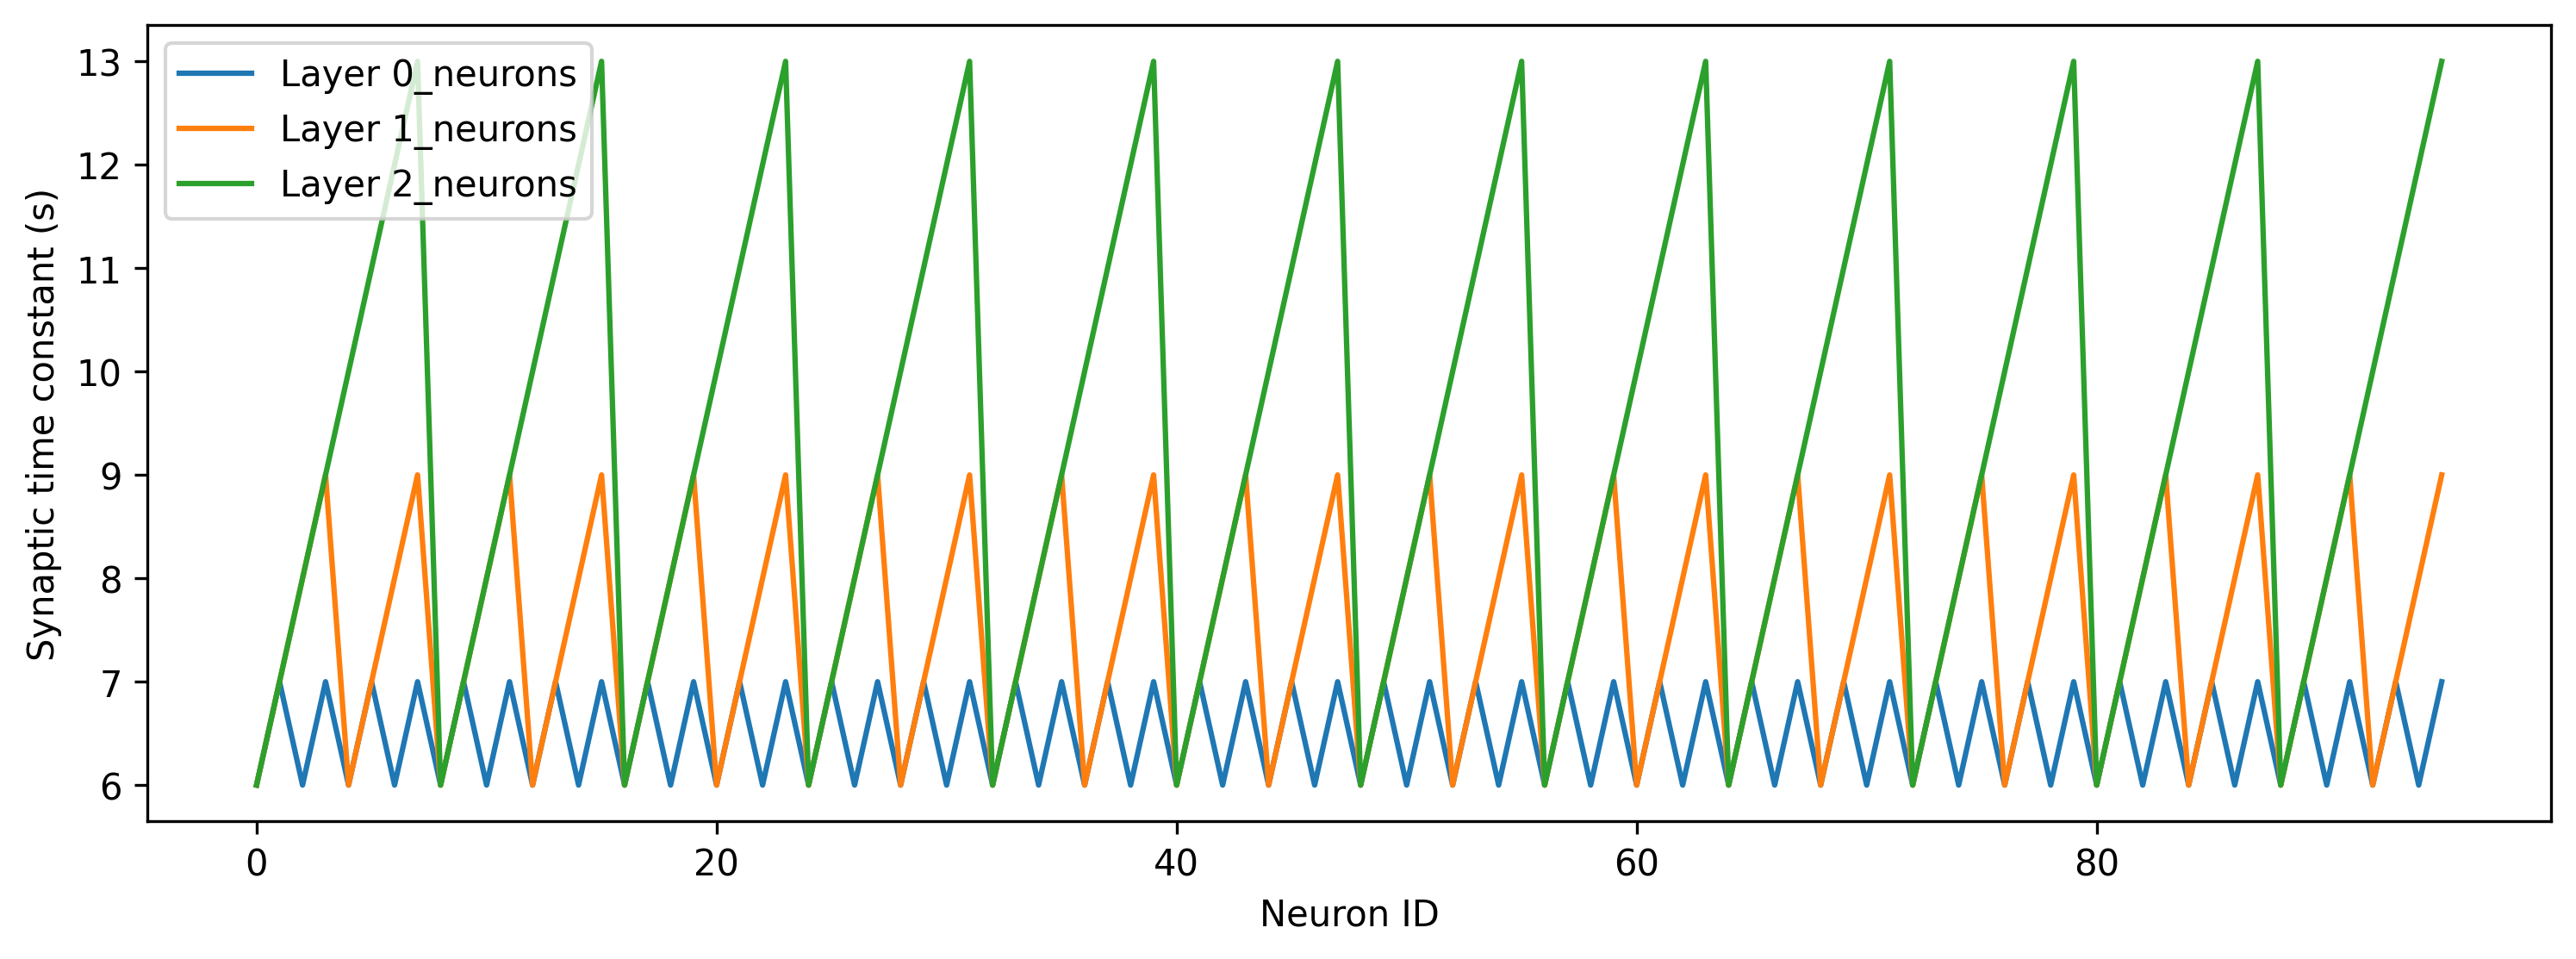

In [22]:
sampleFreq = 64
net = SynNet(
    n_channels=30,
    n_classes=18,
    size_hidden_layers=[96,96,96],
    time_constants_per_layer=[2,4,8],
    tau_syn_base=-(1/64)/np.log(1-2**(-2)),
    tau_mem=-(1/64)/np.log(1-2**(-1)),
    tau_syn_out=-(1/64)/np.log(1-2**(-1)),
    quantize_time_constants=True,
    train_threshold=True,
    max_spikes_per_dt=1,
    max_spikes_per_dt_out=1,
    dt=1e-3,
)

for lyr in net.lif_names[:-1]:
    plt.plot(net.seq[lyr].dash_syn, label = f"Layer {lyr}")

plt.xlabel('Neuron ID')
plt.ylabel('Synaptic time constant (s)')
# plt.yscale('log')
plt.legend();

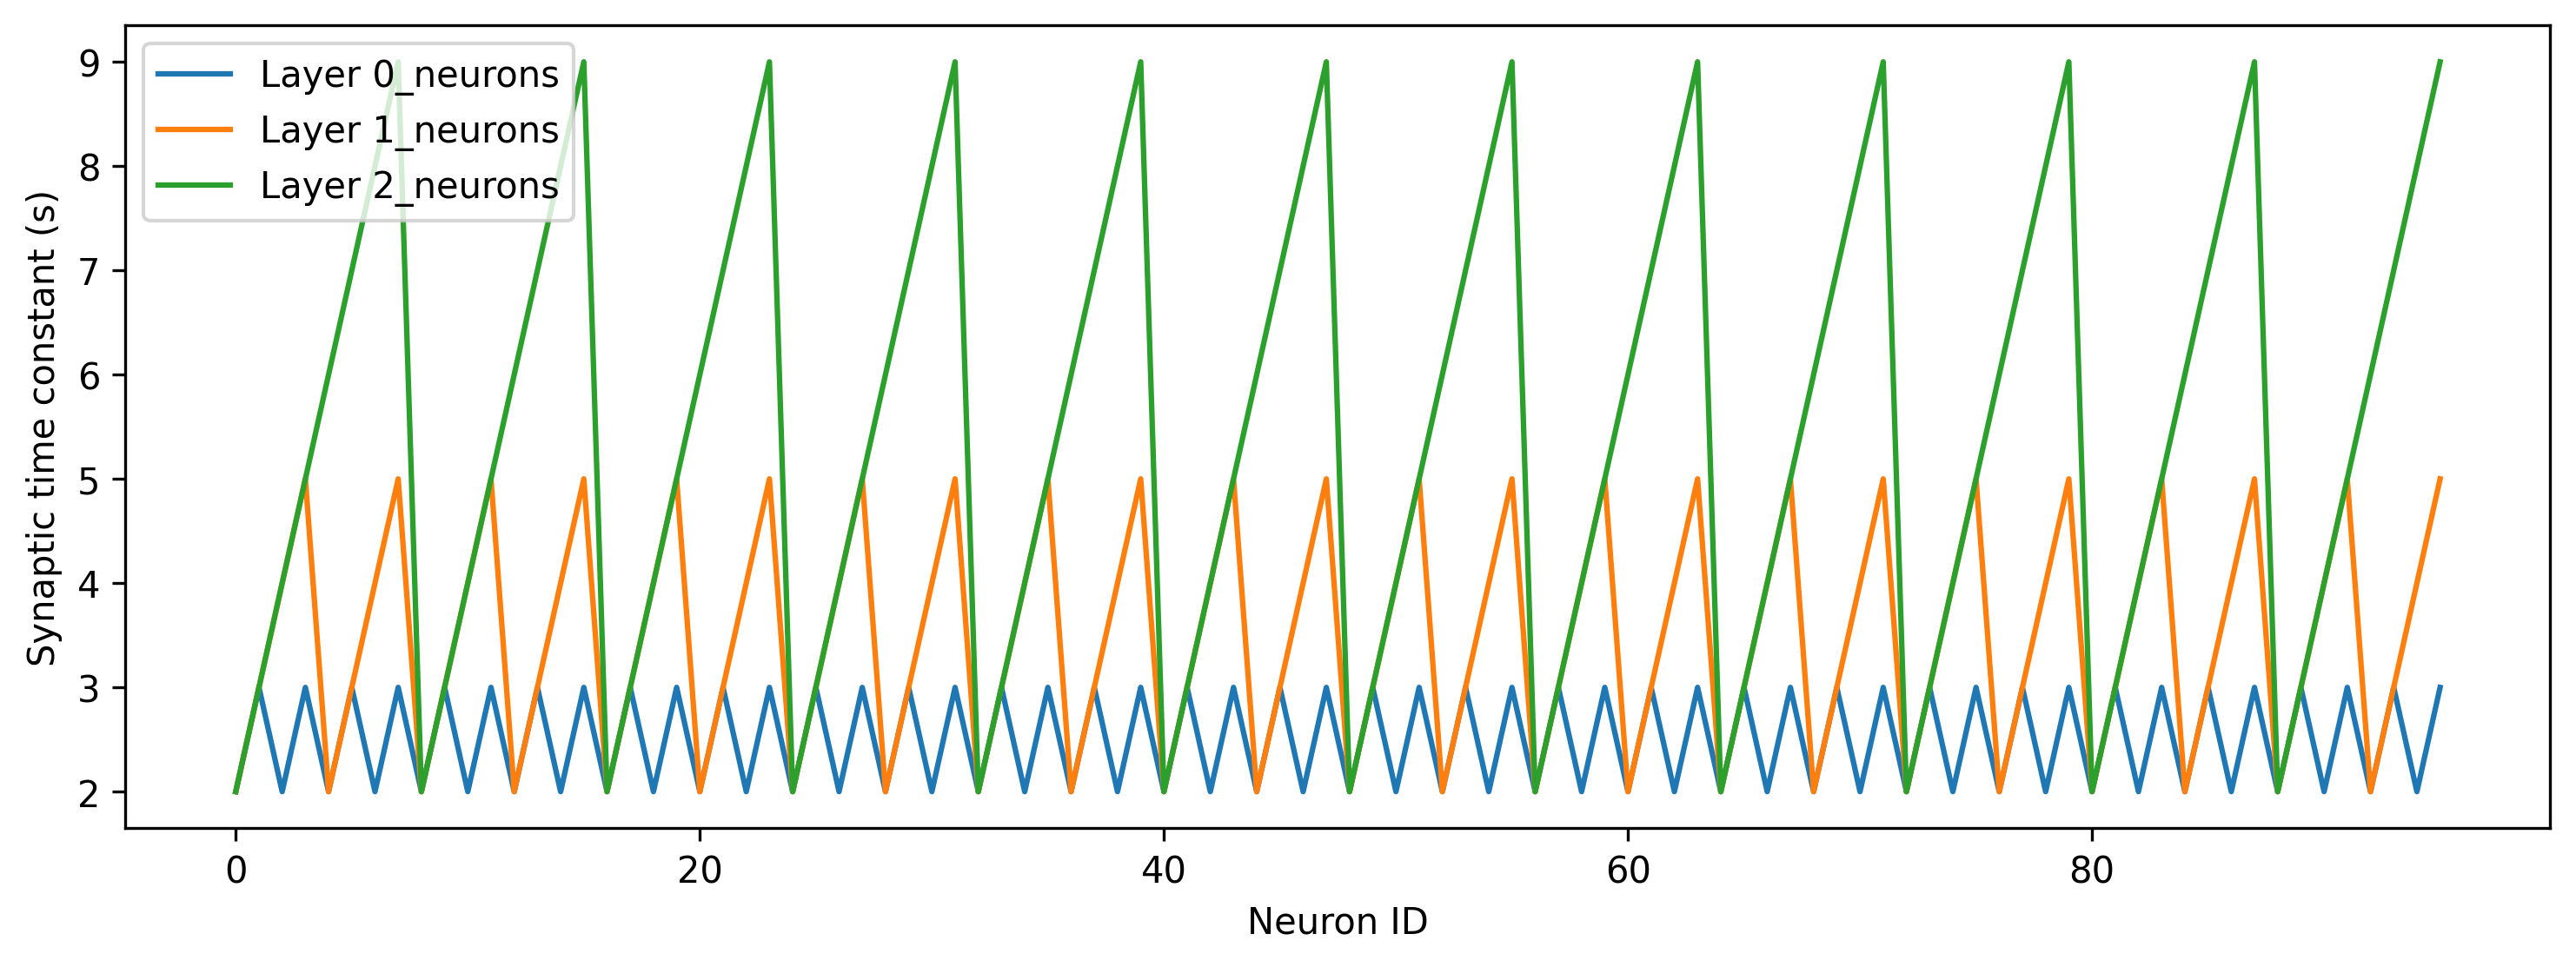

In [27]:
sampleFreq = 16
net = SynNet(
    n_channels=30,
    n_classes=18,
    size_hidden_layers=[96,96,96],
    time_constants_per_layer=[2,4,8],
    tau_syn_base=-(1/sampleFreq)/np.log(1-2**(-2)),
    tau_mem=-(1/sampleFreq)/np.log(1-2**(-1)),
    tau_syn_out=-(1/sampleFreq)/np.log(1-2**(-1)),
    quantize_time_constants=True,
    train_threshold=True,
    max_spikes_per_dt=1,
    max_spikes_per_dt_out=1,
    dt=1/sampleFreq,
)

for lyr in net.lif_names[:-1]:
    plt.plot(net.seq[lyr].dash_syn, label = f"Layer {lyr}")

plt.xlabel('Neuron ID')
plt.ylabel('Synaptic time constant (s)')
# plt.yscale('log')
plt.legend();